In [2]:
# Score Aggregator
# Fetch W&B runs and calculate F1 score statistics

import wandb
import numpy as np
import pandas as pd

In [3]:
# Configuration
ENTITY = "nikhitrivedi1-northeastern-university"
PROJECT = "PatchTST_baseline"  # Change to your project name

print(f"Entity: {ENTITY}")
print(f"Project: {PROJECT}")

Entity: nikhitrivedi1-northeastern-university
Project: PatchTST_baseline


In [4]:
def fetch_runs_from_project(entity, project, filters=None):
    """
    Fetch all runs from a W&B project and get the max F1 score for each.
    
    Args:
        entity: W&B entity/username
        project: W&B project name
        filters: Optional dict of filters (default: finished runs only)
    
    Returns:
        DataFrame with run info and max F1 scores
    """
    if filters is None:
        filters = {"state": "finished"}
    
    api = wandb.Api()
    runs = api.runs(f"{entity}/{project}", filters=filters)
    
    records = []
    for run in runs:
        # Get f1_score history to find max
        history = run.history(keys=["f1_score"])
        f1_values = history["f1_score"].dropna().values
        
        f1_max = np.max(f1_values) if len(f1_values) > 0 else run.summary.get("f1_score")
        
        records.append({
            "run_name": run.name,
            "run_id": run.id,
            "f1_max": f1_max,
            "patch_length": run.config.get("patch_length"),
            "stride": run.config.get("stride"),
            "lr": run.config.get("lr"),
            "num_layers": run.config.get("t_num_layers"),
            "num_heads": run.config.get("t_heads"),
            "lookback_window": run.config.get("lookback_window"),
        })
    
    return pd.DataFrame(records)


def calculate_aggregate_stats(df, group_by=None):
    """
    Calculate aggregate statistics on max F1 scores.
    
    Args:
        df: DataFrame with f1_max column
        group_by: Optional column(s) to group by before calculating stats
    
    Returns:
        dict or DataFrame with statistics
    """
    if group_by is not None:
        # Group by specified column(s) and calculate stats
        stats = df.groupby(group_by)["f1_max"].agg(["mean", "std", "min", "max", "count"])
        stats.columns = ["f1_mean", "f1_std", "f1_min", "f1_max", "num_runs"]
        return stats.reset_index()
    else:
        # Calculate overall stats
        f1_values = df["f1_max"].dropna().values
        return {
            "num_runs": len(f1_values),
            "f1_mean": np.mean(f1_values),
            "f1_std": np.std(f1_values),
            "f1_min": np.min(f1_values),
            "f1_max": np.max(f1_values),
        }

In [5]:
# Fetch all runs from the project
print(f"Fetching runs from {ENTITY}/{PROJECT}...")
df = fetch_runs_from_project(ENTITY, PROJECT)
print(f"Found {len(df)} runs\n")

# Display all runs with their max F1 scores
print("All Runs (sorted by max F1):")
display(df.sort_values("f1_max", ascending=False))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/nikhiltrivedi/.netrc.


Fetching runs from nikhitrivedi1-northeastern-university/PatchTST_baseline...
Found 24 runs

All Runs (sorted by max F1):


,run_name,run_id,f1_max,patch_length,stride,lr,num_layers,num_heads,lookback_window
17,pl64_s16_lr0.001_do0.2_L5_optadamw_h8_wd0p03_c...,obbvbqw3,0.554136,64,16,0.001,5,8,1024
8,pl32_s8_lr0.001_do0.2_L5_optadamw_h8_wd0p03_cl...,js4v6wd0,0.549128,32,8,0.001,5,8,1024
2,pl64_s16_lr0.001_do0.2_L5_optadamw_h8_wd0p03_c...,a5mia6sw,0.544587,64,16,0.001,5,8,1024
9,pl64_s64_lr0.001_do0.2_L5_optadamw_h8_wd0p03_c...,agbbmcca,0.543389,64,64,0.001,5,8,1024
5,pl64_s8_lr0.001_do0.2_L5_optadamw_h8_wd0p03_cl...,gzgic7ik,0.540165,64,8,0.001,5,8,1024
3,pl32_s32_lr0.001_do0.2_L5_optadamw_h8_wd0p03_c...,t5h4zcwf,0.538323,32,32,0.001,5,8,1024
20,pl128_s16_lr0.001_do0.2_L5_optadamw_h8_wd0p03_...,fnfyc3r5,0.537769,128,16,0.001,5,8,1024
16,pl64_s32_lr0.001_do0.2_L5_optadamw_h8_wd0p03_c...,do9vatj9,0.536265,64,32,0.001,5,8,1024
13,pl32_s16_lr0.001_do0.2_L5_optadamw_h8_wd0p03_c...,56i4hnfm,0.535667,32,16,0.001,5,8,1024
10,pl128_s32_lr0.001_do0.2_L5_optadamw_h8_wd0p03_...,ioo0qadr,0.532925,128,32,0.001,5,8,1024


In [6]:
# Calculate aggregate statistics across ALL runs
print("="*60)
print("AGGREGATE STATISTICS (Max F1 across all runs)")
print("="*60)

overall_stats = calculate_aggregate_stats(df)
for key, val in overall_stats.items():
    if isinstance(val, float):
        print(f"  {key}: {val:.4f}")
    else:
        print(f"  {key}: {val}")

AGGREGATE STATISTICS (Max F1 across all runs)
  num_runs: 24
  f1_mean: 0.5297
  f1_std: 0.0194
  f1_min: 0.4455
  f1_max: 0.5541


In [7]:
# Group by specific parameter (e.g., patch_length) and calculate stats
print("="*60)
print("STATISTICS GROUPED BY PATCH LENGTH")
print("="*60)

grouped_stats = calculate_aggregate_stats(df, group_by="patch_length")
display(grouped_stats)

STATISTICS GROUPED BY PATCH LENGTH


,patch_length,f1_mean,f1_std,f1_min,f1_max,num_runs
0,32,0.522338,0.032071,0.445471,0.549128,8
1,64,0.538314,0.009066,0.527918,0.554136,8
2,128,0.528307,0.006093,0.519928,0.537769,8


In [8]:
# Filter runs by specific criteria and recalculate stats
# Example: Only runs with patch_length >= stride (no overlap or touching patches)

df_filtered = df[df["patch_length"] >= df["stride"]].copy()
print(f"Filtered to {len(df_filtered)} runs (patch_length >= stride)")

if len(df_filtered) > 0:
    print("\n" + "="*60)
    print("FILTERED AGGREGATE STATISTICS")
    print("="*60)
    filtered_stats = calculate_aggregate_stats(df_filtered)
    for key, val in filtered_stats.items():
        if isinstance(val, float):
            print(f"  {key}: {val:.4f}")
        else:
            print(f"  {key}: {val}")

Filtered to 22 runs (patch_length >= stride)

FILTERED AGGREGATE STATISTICS
  num_runs: 22
  f1_mean: 0.5300
  f1_std: 0.0203
  f1_min: 0.4455
  f1_max: 0.5541


In [9]:
import matplotlib.pyplot as plt

# Define all W&B project names
project_names = [
    'PatchTST_baseline', 'PatchTST_baseline_test', 
    'PatchTST_w_o_sleep_sitting', 'PatchTST_w_o_sleep_sitting_test', 
    'PatchTST_uniform', 'PatchTST_uniform_test', 
    'PatchTST_uniform_exclude_sleep_sitting', 'PatchTST_uniform_exclude_sleep_sitting_test'
]

# Fetch data from each project and compute aggregate stats
stats_to_plot = []

for project in project_names:
    print(f"Fetching runs from {project}...")
    try:
        project_df = fetch_runs_from_project(ENTITY, project)
        if len(project_df) > 0:
            # Determine if this is a test or validation project
            if project.endswith('_test'):
                run_type = 'test'
                # Base name: remove "PatchTST_" prefix and "_test" suffix
                base_name = project.replace('PatchTST_', '').replace('_test', '')
            else:
                run_type = 'validation'
                # Base name: remove "PatchTST_" prefix
                base_name = project.replace('PatchTST_', '')
            
            mean_f1 = project_df['f1_max'].mean()
            std_f1 = project_df['f1_max'].std()
            
            stats_to_plot.append({
                "project": project,
                "base_name": base_name,
                "run_type": run_type,
                "mean": mean_f1,
                "std": std_f1,
                "num_runs": len(project_df)
            })
            print(f"  Found {len(project_df)} runs, F1: {mean_f1:.4f} ± {std_f1:.4f}")
    except Exception as e:
        print(f"  Error fetching {project}: {e}")

plot_df = pd.DataFrame(stats_to_plot)
print(f"\nTotal projects with data: {len(plot_df)}")
display(plot_df)



Fetching runs from PatchTST_baseline...
  Found 24 runs, F1: 0.5297 ± 0.0199
Fetching runs from PatchTST_baseline_test...
  Found 11 runs, F1: 0.4638 ± 0.0053
Fetching runs from PatchTST_w_o_sleep_sitting...
  Found 12 runs, F1: 0.4865 ± 0.0223
Fetching runs from PatchTST_w_o_sleep_sitting_test...
  Found 12 runs, F1: 0.3963 ± 0.0077
Fetching runs from PatchTST_uniform...
  Found 12 runs, F1: 0.5346 ± 0.0111
Fetching runs from PatchTST_uniform_test...
  Found 11 runs, F1: 0.4533 ± 0.0338
Fetching runs from PatchTST_uniform_exclude_sleep_sitting...
  Found 12 runs, F1: 0.4997 ± 0.0176
Fetching runs from PatchTST_uniform_exclude_sleep_sitting_test...
  Found 12 runs, F1: 0.3943 ± 0.0191

Total projects with data: 8


,project,base_name,run_type,mean,std,num_runs
0,PatchTST_baseline,baseline,validation,0.529653,0.019867,24
1,PatchTST_baseline_test,baseline,test,0.463753,0.005291,11
2,PatchTST_w_o_sleep_sitting,w_o_sleep_sitting,validation,0.486540,0.022306,12
3,PatchTST_w_o_sleep_sitting_test,w_o_sleep_sitting,test,0.396268,0.007715,12
4,PatchTST_uniform,uniform,validation,0.534637,0.011107,12
5,PatchTST_uniform_test,uniform,test,0.453322,0.033778,11
6,PatchTST_uniform_exclude_sleep_sitting,uniform_exclude_sleep_sitting,validation,0.499665,0.017648,12
7,PatchTST_uniform_exclude_sleep_sitting_test,uniform_exclude_sleep_sitting,test,0.394252,0.019081,12


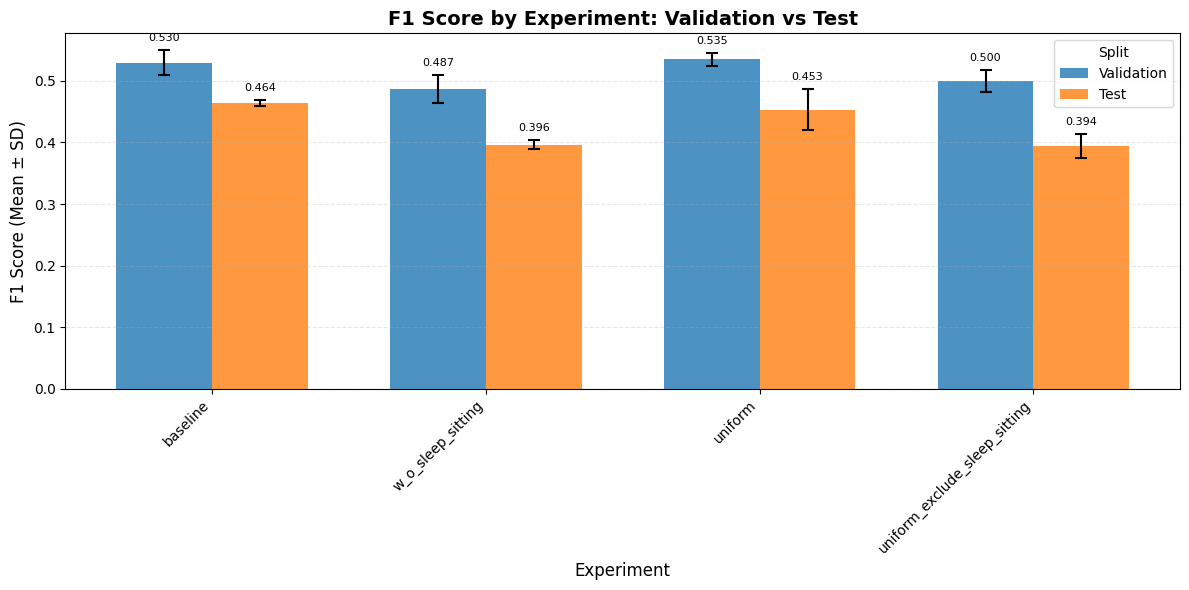


Plot saved as 'f1_validation_vs_test.png'


In [11]:
# Create grouped bar plot: Validation vs Test for each experiment
# X-axis: base experiment name (without PatchTST_ prefix)
# Hue: validation vs test

# Get unique base experiment names (preserving order)
base_names = plot_df['base_name'].unique()
# Sort to ensure consistent order (validation experiments come before their test counterparts)
base_names_ordered = []
for bn in plot_df[plot_df['run_type'] == 'validation']['base_name'].values:
    if bn not in base_names_ordered:
        base_names_ordered.append(bn)

fig, ax = plt.subplots(figsize=(12, 6))
width = 0.35
x = np.arange(len(base_names_ordered))

colors = {'validation': '#1f77b4', 'test': '#ff7f0e'}  # Blue for validation, orange for test

for run_type in ['validation', 'test']:
    subset = plot_df[plot_df['run_type'] == run_type]
    
    # Get values in the correct order matching base_names_ordered
    means = []
    stds = []
    for bn in base_names_ordered:
        row = subset[subset['base_name'] == bn]
        if len(row) > 0:
            means.append(row['mean'].values[0])
            stds.append(row['std'].values[0])
        else:
            means.append(np.nan)
            stds.append(0)
    
    offset = -width/2 if run_type == 'validation' else width/2
    bars = ax.bar(
        x + offset,
        means,
        width,
        yerr=stds,
        label=run_type.capitalize(),
        color=colors[run_type],
        alpha=0.8,
        capsize=4,
        error_kw={'elinewidth': 1.5, 'capthick': 1.5}
    )

# Customize the plot
ax.set_xlabel('Experiment', fontsize=12)
ax.set_ylabel('F1 Score (Mean ± SD)', fontsize=12)
ax.set_title('F1 Score by Experiment: Validation vs Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(base_names_ordered, rotation=45, ha='right', fontsize=10)
ax.legend(title='Split', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars (positioned above the error bars)
for run_type in ['validation', 'test']:
    subset = plot_df[plot_df['run_type'] == run_type]
    offset = -width/2 if run_type == 'validation' else width/2
    for i, bn in enumerate(base_names_ordered):
        row = subset[subset['base_name'] == bn]
        if len(row) > 0:
            val = row['mean'].values[0]
            std = row['std'].values[0] if not np.isnan(row['std'].values[0]) else 0
            # Position label above the error bar (mean + std)
            label_y = val + std
            ax.annotate(f'{val:.3f}', xy=(i + offset, label_y), 
                       xytext=(0, 5), textcoords='offset points',
                       ha='center', va='bottom', fontsize=8, rotation=0)

plt.tight_layout()
plt.savefig('f1_validation_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'f1_validation_vs_test.png'")